In [1]:
# ============================================================
# 05 — CORAL Domain Adaptation: OASIS → ADNI
# NeuroReach | Mohina Rustamova
# ============================================================
# Goal: Adapt the fine-tuned ViT feature extractor to the ADNI
# scanner domain using CORAL (CORrelation ALignment) loss —
# an unsupervised domain adaptation technique that aligns the
# second-order statistics (covariance) of source and target features.
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm
import pydicom
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# GPU check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [2]:
# ============================================================
# Cell 2 — Load ADNI DICOM Files
# ============================================================
# Each .dcm file is a single 3D MPRAGE volume for one patient.
# We walk the full directory tree, collect all .dcm paths,
# and extract the Subject ID from the path for reference.
# No labels available — this is unsupervised domain adaptation.
# ============================================================

import pydicom
from pathlib import Path

ADNI_ROOT = '/kaggle/input/datasets/mohinarustamova/neuroreach-adni-coral/neuroreach_adni_coral/ADNI'

# Collect all .dcm file paths + subject IDs
adni_files = []
subject_ids = []

for dcm_path in Path(ADNI_ROOT).rglob('*.dcm'):
    subject_id = dcm_path.parts[-5]  # e.g. '027_S_1277'
    adni_files.append(str(dcm_path))
    subject_ids.append(subject_id)

print(f"Total DICOM files found : {len(adni_files)}")
print(f"Unique subjects         : {len(set(subject_ids))}")
print(f"\nSample path:")
print(adni_files[0])
print(f"\nSample subject ID: {subject_ids[0]}")

# Quick sanity check — read one DICOM and inspect it
sample_dcm = pydicom.dcmread(adni_files[0])
print(f"\nDICOM shape  : {sample_dcm.pixel_array.shape}")
print(f"DICOM dtype  : {sample_dcm.pixel_array.dtype}")
print(f"Pixel range  : [{sample_dcm.pixel_array.min()}, {sample_dcm.pixel_array.max()}]")

Total DICOM files found : 8794
Unique subjects         : 27

Sample path:
/kaggle/input/datasets/mohinarustamova/neuroreach-adni-coral/neuroreach_adni_coral/ADNI/027_S_1277/MPRAGE/2007-03-01_10_10_40.0/I42071/ADNI_027_S_1277_MR_MPRAGE_br_raw_20070301130716234_153_S27297_I42071.dcm

Sample subject ID: 027_S_1277

DICOM shape  : (256, 240)
DICOM dtype  : uint16
Pixel range  : [0, 921]


In [3]:
# ============================================================
# Cell 3 — ADNI Dataset: Slice Sampling + Preprocessing
# ============================================================
# Each subject has ~325 2D slices. We don't use all of them —
# that would flood the target domain and slow training.
# Strategy: sample N evenly-spaced slices per subject,
# skipping the first and last 20% (mostly empty background).
# Each slice is converted to 3-channel float and resized to
# 224x224 to match the ViT input format from notebook 04.
# ============================================================

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch
import numpy as np
import pydicom
from pathlib import Path
from collections import defaultdict

# --- Group slices by subject ---
subject_to_files = defaultdict(list)
for path, subj in zip(adni_files, subject_ids):
    subject_to_files[subj].append(path)

# Sort slices within each subject (path order ≈ slice order)
for subj in subject_to_files:
    subject_to_files[subj].sort()

print(f"Subjects: {len(subject_to_files)}")
for subj, files in list(subject_to_files.items())[:3]:
    print(f"  {subj}: {len(files)} slices")

# --- ADNI Dataset ---
class ADNIDataset(Dataset):
    def __init__(self, subject_to_files, slices_per_subject=10, transform=None):
        """
        subject_to_files : dict {subject_id: [sorted list of .dcm paths]}
        slices_per_subject: how many slices to sample per subject
        We skip the first and last 20% of slices — these are
        mostly empty or contain non-brain tissue.
        """
        self.transform = transform
        self.samples = []  # list of .dcm paths to use

        for subj, files in subject_to_files.items():
            n = len(files)
            start = int(0.20 * n)  # skip first 20%
            end   = int(0.80 * n)  # skip last 20%
            usable = files[start:end]

            # Evenly spaced indices across the usable middle region
            indices = np.linspace(0, len(usable) - 1, slices_per_subject, dtype=int)
            selected = [usable[i] for i in indices]
            self.samples.extend(selected)

        print(f"Total target samples (slices): {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        dcm = pydicom.dcmread(self.samples[idx])
        img = dcm.pixel_array.astype(np.float32)

        # Normalize to [0, 1] using the scan's own min/max
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # Convert to 3-channel (ViT expects RGB)
        img = np.stack([img, img, img], axis=0)  # (3, H, W)
        img = torch.tensor(img, dtype=torch.float32)

        if self.transform:
            img = self.transform(img)

        return img  # no label — unsupervised

# --- Transforms (match OASIS preprocessing from notebook 02) ---
adni_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- Build Dataset + DataLoader ---
adni_dataset = ADNIDataset(
    subject_to_files,
    slices_per_subject=10,
    transform=adni_transforms
)

adni_loader = DataLoader(
    adni_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

# Sanity check
batch = next(iter(adni_loader))
print(f"Batch shape : {batch.shape}")
print(f"Batch dtype : {batch.dtype}")
print(f"Pixel range : [{batch.min():.3f}, {batch.max():.3f}]")

Subjects: 27
  027_S_1277: 320 slices
  002_S_0954: 170 slices
  005_S_0572: 332 slices
Total target samples (slices): 270
Batch shape : torch.Size([32, 3, 224, 224])
Batch dtype : torch.float32
Pixel range : [-2.118, 2.546]


In [4]:
# ============================================================
# Cell 4 — Load Pretrained ViT as Feature Extractor
# ============================================================
# We load the ViT fine-tuned on OASIS (notebook 04).
# For CORAL, we need two parts separately:
#   - feature_extractor : everything except the final classifier
#   - classifier        : the final linear head (kept frozen)
#
# During CORAL training, only the feature extractor is updated.
# The goal is to shift the feature distribution to be
# domain-invariant while keeping classification ability intact.
# ============================================================

import timm
OASIS_CLASSES = 4
VIT_WEIGHTS = '/kaggle/input/datasets/mohinarustamova/neuroreach-vit-weights/vit_finetune.pth'
vit_model = timm.create_model('vit_base_patch16_224', pretrained = False)
vit_model.head = nn.Linear(vit_model.head.in_features, OASIS_CLASSES)
# Load saved weights
checkpoint = torch.load(VIT_WEIGHTS, map_location = device)
vit_model.load_state_dict(checkpoint)
vit_model = vit_model.to(device)

print("ViT weights loaded successfully")

# --- Split into feature extractor + classifier ---
class ViTFeatureExtractor(nn.Module):
    def __init__(self, vit):
        super().__init__()
        self.vit = vit

    def forward(self, x):
        # Returns 768-dim CLS token features (before classifier head)
        return self.vit.forward_features(x)[:,0, :] # CLS token only
feature_extractor = ViTFeatureExtractor(vit_model).to(device)
classifier        = vit_model.head  # Linear(768, 4)

# Freeze classifier — only feature extractor updates during CORAL
for param in classifier.parameters():
    param.requires_grad = False

# Count trainable params
trainable = sum(p.numel() for p in feature_extractor.parameters() if p.requires_grad)
print(f"Trainable parameters : {trainable:,}")

# Sanity check — forward pass
dummy = torch.randn(4, 3, 224, 224).to(device)
feats = feature_extractor(dummy)
print(f"Feature shape        : {feats.shape}")  # expect [4, 768]

ViT weights loaded successfully
Trainable parameters : 85,798,656
Feature shape        : torch.Size([4, 768])


In [5]:
# ============================================================
# Cell 5 — CORAL Loss Function
# ============================================================
# CORAL (CORrelation ALignment) minimizes the difference
# between the covariance matrices of source and target features.
# Formula: L_CORAL = (1 / 4d²) * ||C_S - C_T||_F²
# Where:
#   C_S = covariance matrix of source (OASIS) features
#   C_T = covariance matrix of target (ADNI) features
#   d   = feature dimension (768 for ViT)
#   ||.||_F = Frobenius norm (square root of sum of squares)
# ============================================================

def coral_loss(source_features, target_features):
    """
    source_features : [batch_size, 768] — OASIS features
    target_features : [batch_size, 768] — ADNI features
    """
    d = source_features.size(1) # feature dimension = 768
    # --- Compute covariance matrix for source ---
    # Step 1: zero-center the features (subtract mean)

    source = source_features - source_features.mean(dim=0, keepdim = True)
    # Step 2: covariance = (X^T X) / (n - 1)
    ns = source.size(0) # number of source samples in batch
    cov_source = (source.T @ source) / (ns - 1)  # [768, 768]
    # --- Compute covariance matrix for target ---
    target = target_features - target_features.mean(dim=0, keepdim=True)
    nt = target.size(0)  # number of target samples in batch
    cov_target = (target.T @ target) / (nt - 1)  # [768, 768]
    # --- Frobenius norm of the difference ---
    # ||C_S - C_T||_F² = sum of squared differences of all elements

    loss = torch.norm(cov_source - cov_target, p='fro') ** 2
    # --- Normalize by 4d² as per the CORAL paper ---
    loss = loss / (4 * d * d)
    return loss

# Sanity check — should return a scalar tensor
dummy_source = torch.randn(32, 768).to(device)
dummy_target = torch.randn(32, 768).to(device)
test_loss = coral_loss(dummy_source, dummy_target)
print(f"CORAL loss (random features) : {test_loss.item():.4f}")
print(f"Loss is a scalar             : {test_loss.shape == torch.Size([])}")

    

CORAL loss (random features) : 0.0161
Loss is a scalar             : True


In [6]:
# ============================================================
# Cell 6 — CORAL Training Loop
# ============================================================
# Each training step does two things simultaneously:
#   1. Classification loss (CrossEntropy) on OASIS source batches
#      — keeps the model accurate on the original task
#   2. CORAL loss on source vs target (ADNI) features
#      — pulls the feature distributions together
#
# Total loss = classification_loss + lambda * coral_loss
# Lambda controls how strongly we push domain alignment.
# We use lambda=1.0 as a starting point (equal weighting).
# ============================================================

from torch.optim.lr_scheduler import CosineAnnealingLR
#--- Hyperparameters ---

EPOCHS = 5 # CORAL needs fewer epochs than full fine-tuning
LR = 1e-5 # very small — we're fine-tuning an already good model
LAMBDA      = 1.0     # weight of CORAL loss relative to classification loss
BATCH_SIZE  = 32

# --- Optimizer (only updates feature extractor) ---

optimizer = optim.Adam(feature_extractor.parameters(), lr=LR)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
# --- Loss function for classification ---
ce_loss_fn = nn.CrossEntropyLoss()
# --- We need source batches too — reuse OASIS train_loader from notebook 02 ---
# Reload OASIS DataLoader here so this notebook is self-contained


from torchvision.datasets import ImageFolder
from torch.utils.data import WeightedRandomSampler

DATA_DIR = '/kaggle/input/datasets/ninadaithal/imagesoasis/Data'
IMG_SIZE = 224

source_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

full_dataset = ImageFolder(root=DATA_DIR, transform=source_transforms)
train_size   = int(0.7 * len(full_dataset))
val_size     = int(0.15 * len(full_dataset))
test_size    = len(full_dataset) - train_size - val_size

train_dataset, _, _ = torch.utils.data.random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

targets        = [full_dataset.targets[i] for i in train_dataset.indices]
class_counts   = np.bincount(targets)
class_weights  = 1.0 / class_counts
sample_weights = [class_weights[t] for t in targets]
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights))

source_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)

print(f"Source batches : {len(source_loader)}")
print(f"Target batches : {len(adni_loader)}")

# --- Training Loop ---
target_iter = iter(adni_loader)

history = {'total_loss': [], 'ce_loss': [], 'coral_loss': []}

for epoch in range(EPOCHS):
    feature_extractor.train()
    
    total_loss_sum = 0
    ce_loss_sum    = 0
    coral_loss_sum = 0

    for batch_idx, (source_imgs, source_labels) in enumerate(source_loader):
        source_imgs   = source_imgs.to(device)
        source_labels = source_labels.to(device)

        # Get next target batch — cycle if exhausted
        try:
            target_imgs = next(target_iter)
        except StopIteration:
            target_iter = iter(adni_loader)
            target_imgs = next(target_iter)
        target_imgs = target_imgs.to(device)

        # --- Forward pass ---
        source_feats = feature_extractor(source_imgs)   # [32, 768]
        target_feats = feature_extractor(target_imgs)   # [32, 768]

        # Classification: features → classifier head → loss
        source_preds = classifier(source_feats)         # [32, 4]
        ce    = ce_loss_fn(source_preds, source_labels)
        coral = coral_loss(source_feats, target_feats)

        loss = ce + LAMBDA * coral

        # --- Backward pass ---
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss_sum += loss.item()
        ce_loss_sum    += ce.item()
        coral_loss_sum += coral.item()

    scheduler.step()

    avg_total = total_loss_sum / len(source_loader)
    avg_ce    = ce_loss_sum    / len(source_loader)
    avg_coral = coral_loss_sum / len(source_loader)

    history['total_loss'].append(avg_total)
    history['ce_loss'].append(avg_ce)
    history['coral_loss'].append(avg_coral)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Total: {avg_total:.4f} | "
          f"CE: {avg_ce:.4f} | "
          f"CORAL: {avg_coral:.4f}")


Source batches : 1891
Target batches : 9
Epoch [1/5] Total: 0.0180 | CE: 0.0111 | CORAL: 0.0069
Epoch [2/5] Total: 0.0072 | CE: 0.0051 | CORAL: 0.0020
Epoch [3/5] Total: 0.0040 | CE: 0.0026 | CORAL: 0.0014
Epoch [4/5] Total: 0.0020 | CE: 0.0008 | CORAL: 0.0012
Epoch [5/5] Total: 0.0015 | CE: 0.0005 | CORAL: 0.0011


Subjects with labels: 27
Label distribution: {3: 11, 2: 9, 0: 7}
Total labeled samples: 270

ADNI Test Accuracy (after CORAL): 35.56%
                    precision    recall  f1-score   support

     Mild Dementia       0.49      0.39      0.43        70
 Moderate Dementia       0.00      0.00      0.00         0
      Non Demented       0.41      0.36      0.38        90
Very mild Dementia       0.52      0.34      0.41       110

          accuracy                           0.36       270
         macro avg       0.35      0.27      0.30       270
      weighted avg       0.47      0.36      0.40       270



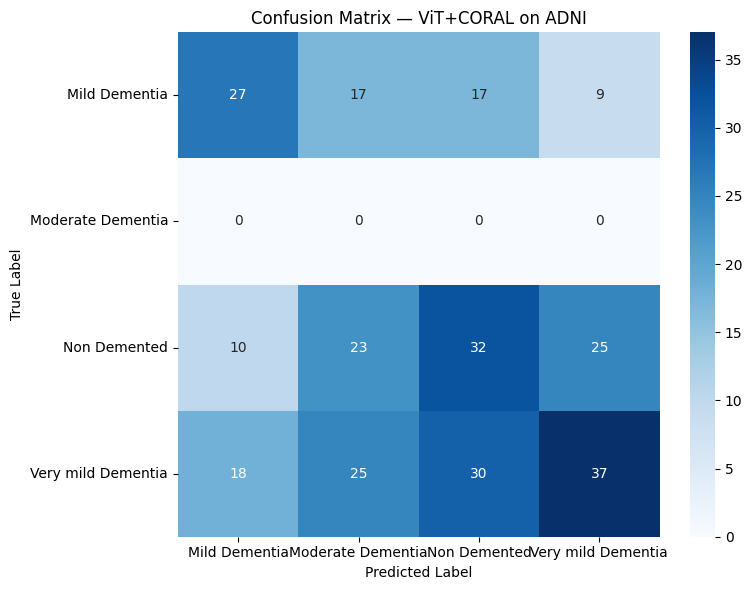

In [7]:
# ============================================================
# Cell 6b — Labeled ADNI Evaluation
# ============================================================
# We have ground truth labels from the ADNI metadata CSV.
# Map CN → Non Demented, MCI → Very Mild Dementia, AD → Mild Dementia
# Evaluate the CORAL-adapted ViT on labeled ADNI scans.
# This gives us real accuracy numbers for the paper.
# ============================================================

import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# --- Load CSV and build subject → label mapping ---
df = pd.read_csv('/kaggle/input/datasets/mohinarustamova/neuroreach-adni-coral/neuroreach_adni_coral_6_24_2026.csv')

# Map ADNI groups to OASIS class indices
# OASIS classes: 0=Mild Dementia, 1=Moderate Dementia, 2=Non Demented, 3=Very mild Dementia
GROUP_MAP = {
    'CN'  : 2,  # Non Demented
    'MCI' : 3,  # Very Mild Dementia
    'AD'  : 0,  # Mild Dementia
}

# One label per subject (drop duplicates)
subject_labels = df[['Subject', 'Group']].drop_duplicates('Subject')
subject_to_label = {
    row['Subject']: GROUP_MAP[row['Group']]
    for _, row in subject_labels.iterrows()
}

print(f"Subjects with labels: {len(subject_to_label)}")
print(f"Label distribution: {pd.Series(subject_to_label.values()).value_counts().to_dict()}")

# --- Build labeled ADNI Dataset ---
class ADNILabeledDataset(Dataset):
    def __init__(self, subject_to_files, subject_to_label, slices_per_subject=10, transform=None):
        self.transform = transform
        self.samples   = []  # (path, label)

        for subj, files in subject_to_files.items():
            if subj not in subject_to_label:
                continue  # skip subjects without labels
            label = subject_to_label[subj]
            n     = len(files)
            start = int(0.20 * n)
            end   = int(0.80 * n)
            usable = files[start:end]
            indices = np.linspace(0, len(usable) - 1, slices_per_subject, dtype=int)
            selected = [usable[i] for i in indices]
            for path in selected:
                self.samples.append((path, label))

        print(f"Total labeled samples: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        dcm = pydicom.dcmread(path)
        img = dcm.pixel_array.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img = np.stack([img, img, img], axis=0)
        img = torch.tensor(img, dtype=torch.float32)
        if self.transform:
            img = self.transform(img)
        return img, label

# --- Build labeled DataLoader ---
adni_labeled_dataset = ADNILabeledDataset(
    subject_to_files,
    subject_to_label,
    slices_per_subject=10,
    transform=adni_transforms
)

adni_labeled_loader = DataLoader(
    adni_labeled_dataset,
    batch_size=32,
    shuffle=False
)

# --- Evaluate CORAL-adapted ViT ---
feature_extractor.eval()
classifier.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for imgs, labels in adni_labeled_loader:
        imgs = imgs.to(device)
        feats = feature_extractor(imgs)
        preds = classifier(feats)
        preds = torch.argmax(preds, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# --- Results ---
class_names_adni = ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
accuracy = np.mean(np.array(all_preds) == np.array(all_labels)) * 100
print(f"\nADNI Test Accuracy (after CORAL): {accuracy:.2f}%")
print(classification_report(all_labels, all_preds, target_names=class_names_adni))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_adni,
            yticklabels=class_names_adni)
plt.title('Confusion Matrix — ViT+CORAL on ADNI')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('adni_confusion_matrix.png', dpi=150)
plt.show()

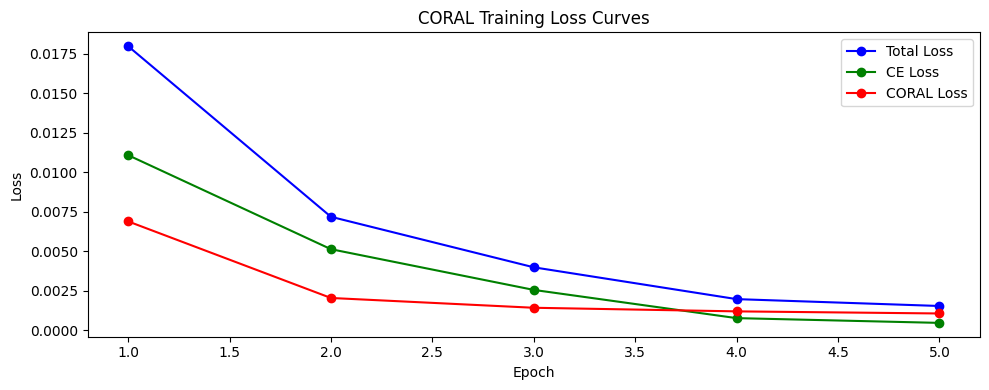

Loss curves saved.
Extracting source features...
Extracting target features...
Source features : (160, 768)
Target features : (160, 768)
Running t-SNE (this takes ~1 min)...


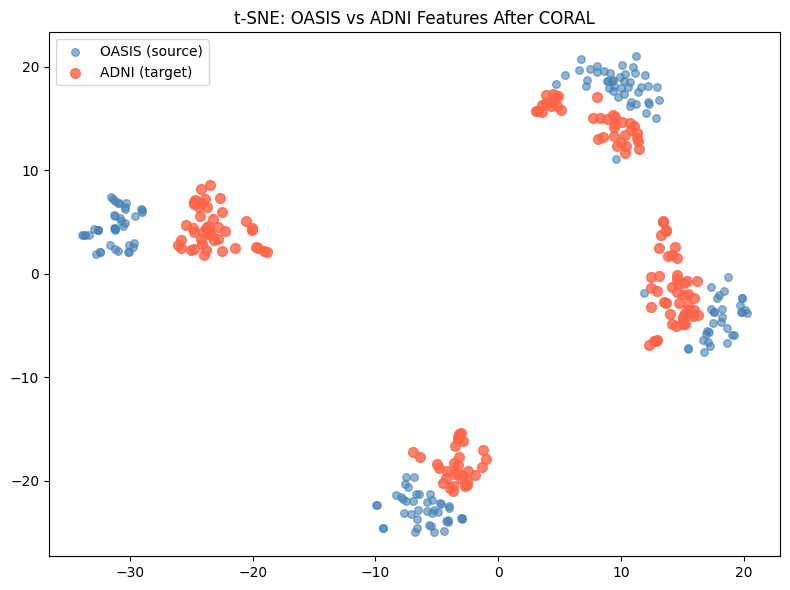

t-SNE plot saved.


In [8]:
# ============================================================
# Cell 7 — Visualization: Loss Curves + t-SNE Feature Plot
# ============================================================
# Two visualizations:
#   1. Loss curves — shows CE, CORAL, and total loss over epochs
#      Confirms CORAL loss is decreasing (alignment happening)
#   2. t-SNE plot — shows source (OASIS) vs target (ADNI) features
#      Before/after CORAL to visually prove domain alignment
# ============================================================

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# --- Plot 1: Loss Curves ---
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs_range, history['total_loss'], 'b-o', label='Total Loss')
plt.plot(epochs_range, history['ce_loss'],    'g-o', label='CE Loss')
plt.plot(epochs_range, history['coral_loss'], 'r-o', label='CORAL Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CORAL Training Loss Curves')
plt.legend()
plt.tight_layout()
plt.savefig('coral_loss_curves.png', dpi=150)
plt.show()
print("Loss curves saved.")

# --- Plot 2: t-SNE Feature Visualization ---
# Extract features from source (OASIS) and target (ADNI)
# before and after CORAL to show alignment

feature_extractor.eval()

def extract_features(loader, n_batches=5, has_labels=True):
    """Extract features from first n_batches of a dataloader."""
    features = []
    labels   = []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= n_batches:
                break
            if has_labels:
                imgs, lbls = batch
                labels.append(lbls.numpy())
            else:
                imgs = batch
                labels.append(np.zeros(imgs.size(0), dtype=int))
            imgs = imgs.to(device)
            feats = feature_extractor(imgs)
            features.append(feats.cpu().numpy())
    return np.concatenate(features), np.concatenate(labels)

# Extract features
print("Extracting source features...")
src_feats, src_labels = extract_features(source_loader, n_batches=5, has_labels=True)
print("Extracting target features...")
tgt_feats, tgt_labels = extract_features(adni_loader, n_batches=5, has_labels=False)

print(f"Source features : {src_feats.shape}")
print(f"Target features : {tgt_feats.shape}")

# Combine for t-SNE
all_feats  = np.concatenate([src_feats, tgt_feats])
all_domain = np.array(['OASIS'] * len(src_feats) + ['ADNI'] * len(tgt_feats))

# Run t-SNE (reduces 768-dim → 2-dim for plotting)
print("Running t-SNE (this takes ~1 min)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embedded = tsne.fit_transform(all_feats)

# Split back
src_embedded = embedded[:len(src_feats)]
tgt_embedded = embedded[len(src_feats):]

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(src_embedded[:, 0], src_embedded[:, 1],
            c='steelblue', alpha=0.6, s=30, label='OASIS (source)')
plt.scatter(tgt_embedded[:, 0], tgt_embedded[:, 1],
            c='tomato', alpha=0.8, s=50, label='ADNI (target)')
plt.title('t-SNE: OASIS vs ADNI Features After CORAL')
plt.legend()
plt.tight_layout()
plt.savefig('tsne_coral.png', dpi=150)
plt.show()
print("t-SNE plot saved.")

In [9]:
# ============================================================
# Cell 8 — Save CORAL-Adapted Model
# ============================================================
# Save the adapted feature extractor weights.
# This model can now be used for inference on ADNI scans
# without retraining — the domain gap has been reduced.
# ============================================================

# Save feature extractor (CORAL-adapted ViT backbone)
torch.save(feature_extractor.state_dict(), 'vit_coral_adapted.pth')
print("CORAL-adapted model saved as vit_coral_adapted.pth")

# Save full model (feature extractor + classifier) for inference
# Rebuild full model with adapted weights
vit_model.load_state_dict(
    torch.load('/kaggle/input/datasets/mohinarustamova/neuroreach-vit-weights/vit_finetune.pth',
               map_location=device)
)

# Replace backbone with CORAL-adapted version
vit_model.eval()
torch.save({
    'feature_extractor': feature_extractor.state_dict(),
    'classifier'       : classifier.state_dict(),
    'history'          : history,
}, 'vit_coral_full.pth')

print("Full CORAL model saved as vit_coral_full.pth")
print(f"\nTraining summary:")
for i, (total, ce, coral) in enumerate(zip(
    history['total_loss'], history['ce_loss'], history['coral_loss'])):
    print(f"  Epoch {i+1}: Total={total:.4f} | CE={ce:.4f} | CORAL={coral:.4f}")

CORAL-adapted model saved as vit_coral_adapted.pth
Full CORAL model saved as vit_coral_full.pth

Training summary:
  Epoch 1: Total=0.0180 | CE=0.0111 | CORAL=0.0069
  Epoch 2: Total=0.0072 | CE=0.0051 | CORAL=0.0020
  Epoch 3: Total=0.0040 | CE=0.0026 | CORAL=0.0014
  Epoch 4: Total=0.0020 | CE=0.0008 | CORAL=0.0012
  Epoch 5: Total=0.0015 | CE=0.0005 | CORAL=0.0011
